In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Exact values

In [2]:
import scipy
from scipy.special import erf
import numpy
from numpy import exp
from numpy.lib.scimath import log, sqrt

# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call, put = black_scholes(S0, K, T, r, sigma)
    print(" == BLACK-SCHOLES ==")
    print("call: ", call)
    print("put: ", put)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


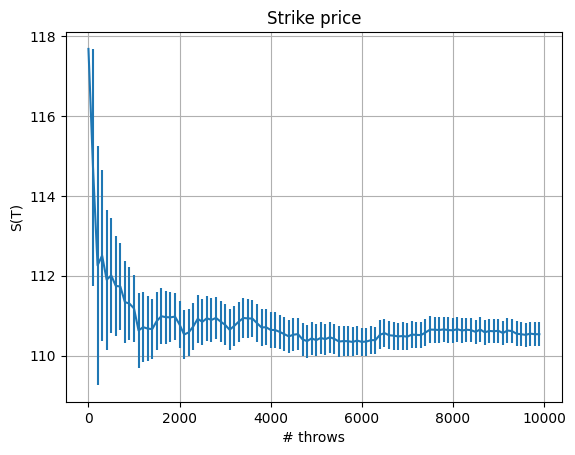

In [3]:
df=pd.read_csv('data/strike_priceT.csv')

plt.title('Strike price')
plt.errorbar(df.throws, df.avg, yerr=df.err)
plt.grid(True)

plt.xlabel('# throws')
plt.ylabel('S(T)')
plt.show()

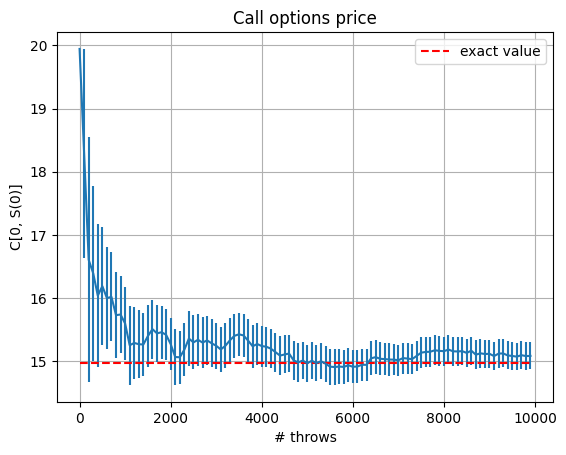

In [4]:
calldf=pd.read_csv('data/call_priceT.csv')
plt.title('Call options price')
plt.errorbar(calldf.throws, calldf.avg, yerr=calldf.err)
plt.hlines(
    call, 
    0, calldf.throws[len(calldf)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
plt.grid(True)
plt.legend()
plt.xlabel('# throws')
plt.ylabel('C[0, S(0)]')
plt.show()



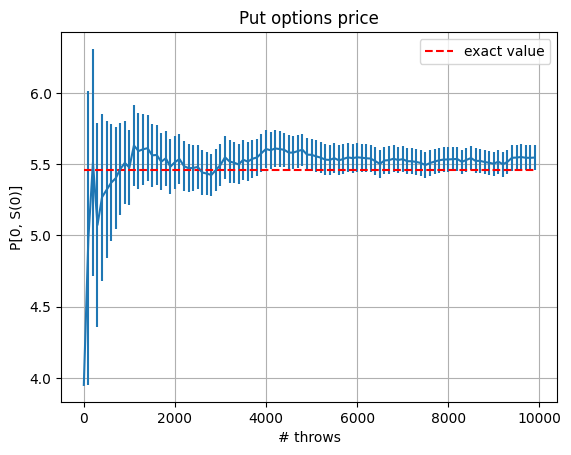

In [55]:
putdf=pd.read_csv('data/put_priceT.csv')
plt.title('Put options price')
plt.errorbar(putdf.throws, putdf.avg, yerr=putdf.err)
plt.hlines(
    put, 
    0, putdf.throws[len(putdf)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
plt.grid(True)
plt.legend()
plt.xlabel('# throws')
plt.ylabel('P[0, S(0)]')
plt.show()



# Progressive

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


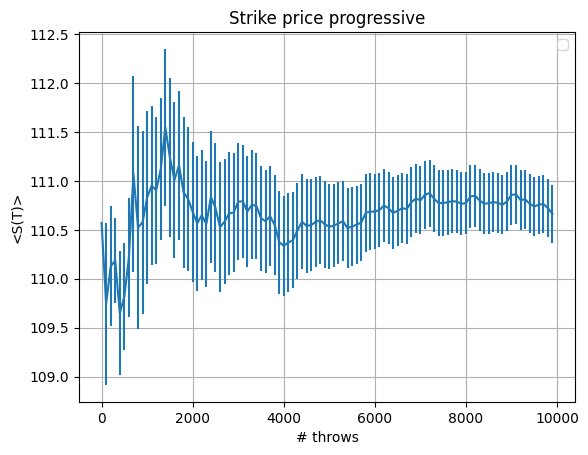

In [56]:
sp=pd.read_csv('data/strike_priceT_progressive.csv')

plt.title('Strike price progressive')
plt.errorbar(sp.throws, sp.avg, yerr=sp.err)
plt.grid(True)
plt.legend()
plt.xlabel('# throws')
plt.ylabel('<S(T)>')
plt.show()



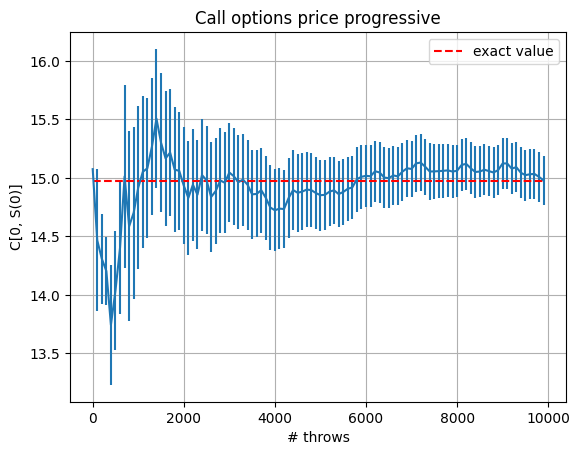

In [60]:
cp=pd.read_csv('data/call_priceT_progressive.csv')

plt.title('Call options price progressive')
plt.errorbar(cp.throws, cp.avg, yerr=cp.err)
plt.hlines(
    call, 
    0, cp.throws[len(cp)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
plt.grid(True)
plt.legend()
plt.xlabel('# throws')
plt.ylabel('C[0, S(0)]')
plt.show()



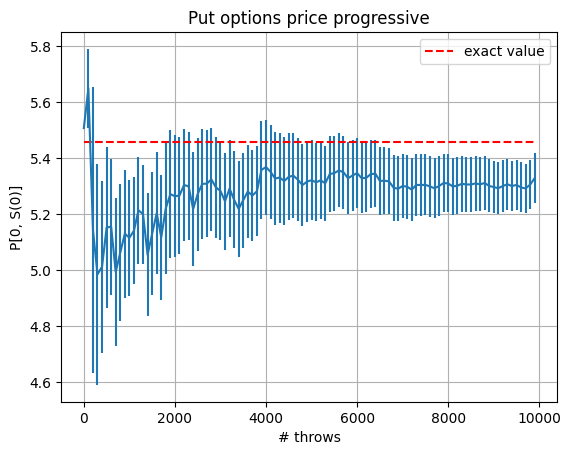

In [61]:
pp=pd.read_csv('data/put_priceT_progressive.csv')

plt.title('Put options price progressive')
plt.errorbar(pp.throws, pp.avg, yerr=pp.err)
plt.hlines(
    put, 
    0, pp.throws[len(pp)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
plt.grid(True)
plt.legend()
plt.xlabel('# throws')
plt.ylabel('P[0, S(0)]')
plt.show()



# Comparison

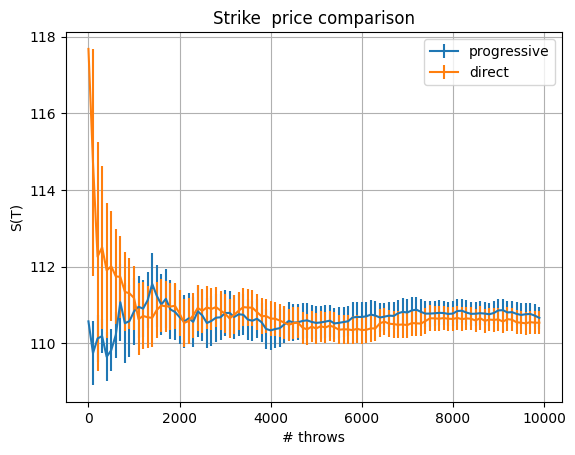

In [62]:
plt.title('Strike  price comparison')
plt.errorbar(sp.throws, sp.avg, yerr=sp.err, label='progressive')
plt.errorbar(df.throws, df.avg, yerr=df.err, label='direct')


plt.grid(True)
plt.legend()
plt.xlabel('# throws')
plt.ylabel('S(T)')
plt.show()



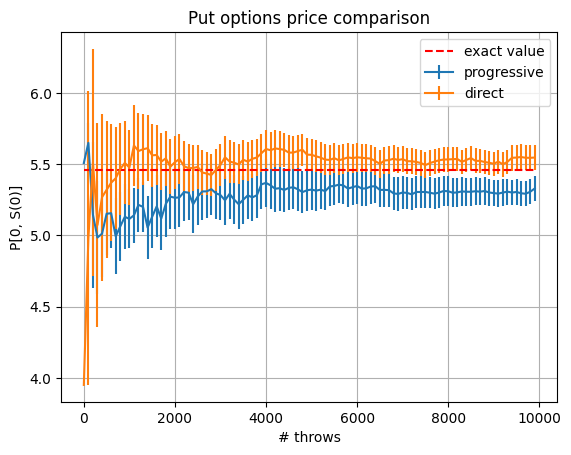

In [64]:
plt.title('Put options price comparison')
plt.errorbar(pp.throws, pp.avg, yerr=pp.err, label='progressive')
plt.errorbar(putdf.throws, putdf.avg, yerr=putdf.err, label='direct')
plt.hlines(
    put, 
    0, putdf.throws[len(putdf)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
plt.grid(True)
plt.legend()
plt.xlabel('# throws')
plt.ylabel('P[0, S(0)]')
plt.show()



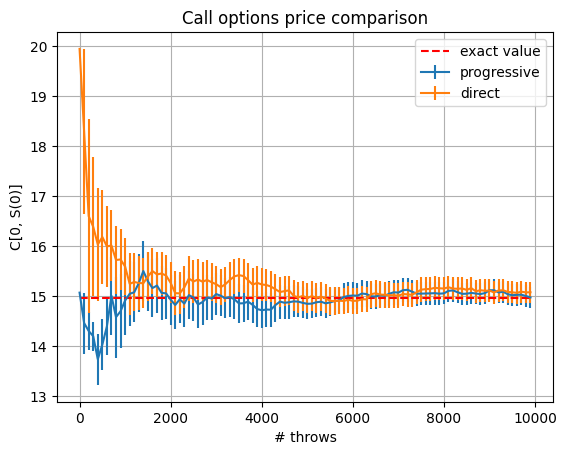

In [65]:
plt.title('Call options price comparison')
plt.errorbar(cp.throws, cp.avg, yerr=cp.err, label='progressive')
plt.errorbar(calldf.throws, calldf.avg, yerr=calldf.err, label='direct')
plt.hlines(
    call, 
    0, calldf.throws[len(calldf)-1], 
    colors='r', linestyles='--',
    label='exact value'
)
plt.grid(True)
plt.legend()
plt.xlabel('# throws')
plt.ylabel('C[0, S(0)]')
plt.show()

